IDEAL DEUTSCH CIRCUIT


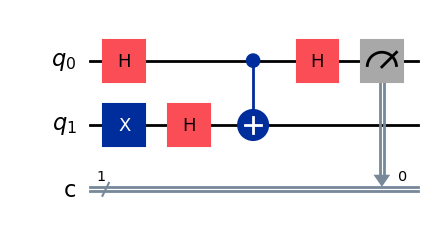

Ideal measurement:
{'1': 5000}

IMPERFECT DEUTSCH CIRCUIT


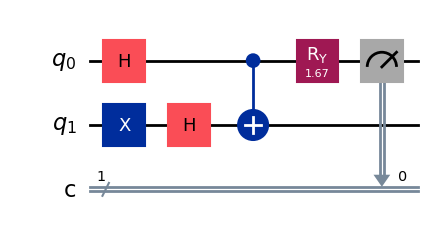

Imperfect measurement:
{'0': 4991, '1': 9}

RELIABILITY
Ideal Hadamard      : 100.00%
Imperfect Hadamard  : 0.18%
Degradation         : 99.82 percentage points

ERROR STUDY
Error =  0.00 rad   Reliability = 100.00%
Error =  0.02 rad   Reliability =   0.00%
Error =  0.05 rad   Reliability =   0.04%
Error =  0.10 rad   Reliability =   0.36%
Error =  0.20 rad   Reliability =   0.94%
Error =  0.30 rad   Reliability =   2.44%
Error =  0.50 rad   Reliability =   5.60%


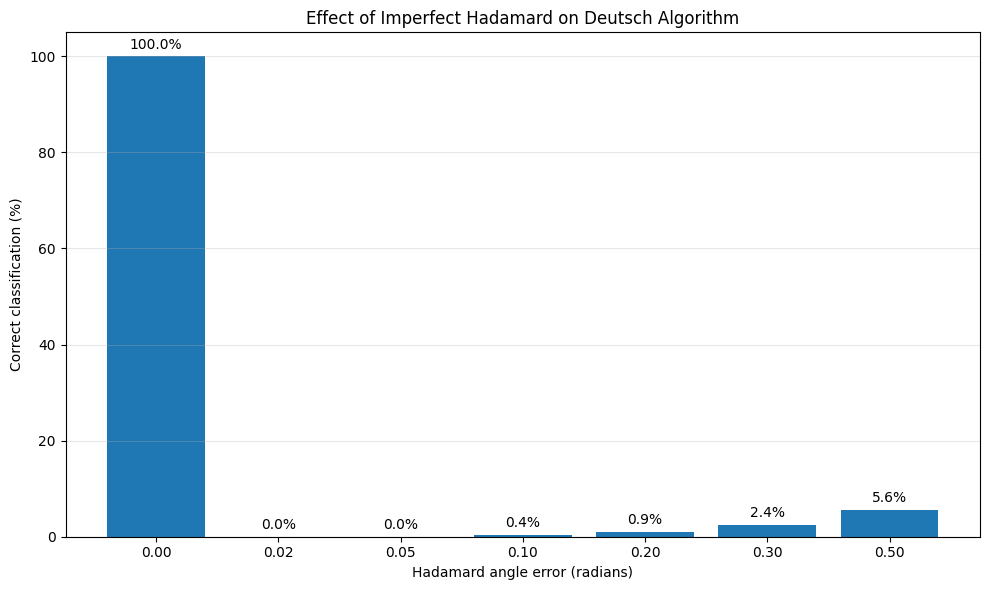

In [1]:
# ============================================================
# CHALLENGE: Deutsch Algorithm with an Imperfect Hadamard Gate
# ============================================================

# If required, run this first:
# %pip install qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

SHOTS = 5000

# Error values in radians
ERRORS = [
    0.00,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50
]


# ------------------------------------------------------------
# 2. Create Deutsch circuit
# ------------------------------------------------------------

def create_deutsch_circuit(error=0.0):
    
    # q0 = input qubit
    # q1 = ancilla qubit
    qc = QuantumCircuit(2, 1)

    # --------------------------------------------------------
    # Step 1: Prepare input qubit |+>
    # --------------------------------------------------------
    qc.h(0)

    # --------------------------------------------------------
    # Step 2: Prepare ancilla in |->
    # --------------------------------------------------------
    qc.x(1)
    qc.h(1)

    # --------------------------------------------------------
    # Step 3: Balanced oracle f(x) = x
    #
    # CNOT implements:
    # |x,y> -> |x, y XOR x>
    # --------------------------------------------------------
    qc.cx(0, 1)

    # --------------------------------------------------------
    # Step 4: Final Hadamard
    #
    # Ideal:
    #       H
    #
    # Imperfect:
    #       RY(pi/2 + error)
    # --------------------------------------------------------

    if error == 0:
        qc.h(0)
    else:
        qc.ry(np.pi / 2 + error, 0)

    # --------------------------------------------------------
    # Step 5: Measure input qubit
    # --------------------------------------------------------
    qc.measure(0, 0)

    return qc


# ------------------------------------------------------------
# 3. Test the ideal circuit
# ------------------------------------------------------------

ideal_circuit = create_deutsch_circuit(0)

print("IDEAL DEUTSCH CIRCUIT")
print("=====================")

display(ideal_circuit.draw("mpl"))


# Run ideal circuit
simulator = AerSimulator()

ideal_result = simulator.run(
    ideal_circuit,
    shots=SHOTS
).result()

ideal_counts = ideal_result.get_counts()

print("Ideal measurement:")
print(ideal_counts)


# ------------------------------------------------------------
# 4. Test one imperfect circuit
# ------------------------------------------------------------

error = 0.10

imperfect_circuit = create_deutsch_circuit(error)

print("\nIMPERFECT DEUTSCH CIRCUIT")
print("=========================")

display(imperfect_circuit.draw("mpl"))

imperfect_result = simulator.run(
    imperfect_circuit,
    shots=SHOTS
).result()

imperfect_counts = imperfect_result.get_counts()

print("Imperfect measurement:")
print(imperfect_counts)


# ------------------------------------------------------------
# 5. Calculate reliability
# ------------------------------------------------------------

# Because f(x)=x is balanced,
# the correct answer is always 1.

ideal_correct = ideal_counts.get("1", 0)
imperfect_correct = imperfect_counts.get("1", 0)

ideal_reliability = (
    ideal_correct / SHOTS
) * 100

imperfect_reliability = (
    imperfect_correct / SHOTS
) * 100

print("\nRELIABILITY")
print("===========")

print(
    f"Ideal Hadamard      : "
    f"{ideal_reliability:.2f}%"
)

print(
    f"Imperfect Hadamard  : "
    f"{imperfect_reliability:.2f}%"
)

print(
    f"Degradation         : "
    f"{ideal_reliability - imperfect_reliability:.2f} "
    f"percentage points"
)


# ------------------------------------------------------------
# 6. Study different error values
# ------------------------------------------------------------

reliabilities = []

for error in ERRORS:

    circuit = create_deutsch_circuit(error)

    result = simulator.run(
        circuit,
        shots=SHOTS
    ).result()

    counts = result.get_counts()

    # Correct answer = 1
    correct = counts.get("1", 0)

    reliability = (
        correct / SHOTS
    ) * 100

    reliabilities.append(reliability)


# ------------------------------------------------------------
# 7. Print results
# ------------------------------------------------------------

print("\nERROR STUDY")
print("===========")

for error, reliability in zip(
    ERRORS,
    reliabilities
):

    print(
        f"Error = {error:>5.2f} rad   "
        f"Reliability = {reliability:>6.2f}%"
    )


# ------------------------------------------------------------
# 8. Bar chart
# ------------------------------------------------------------

labels = [
    f"{error:.2f}"
    for error in ERRORS
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    labels,
    reliabilities
)

plt.xlabel(
    "Hadamard angle error (radians)"
)

plt.ylabel(
    "Correct classification (%)"
)

plt.title(
    "Effect of Imperfect Hadamard on Deutsch Algorithm"
)

plt.ylim(0, 105)

plt.grid(
    axis="y",
    alpha=0.3
)

# Display percentage above each bar
for bar, value in zip(
    bars,
    reliabilities
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()